In [9]:
import marimo as mo
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Trabalho Computacional 1 — Comunicação Digital

Este notebook implementa:
- códigos de linha **polar**, **on-off** e **bipolar (AMI)**;
- pulsos $\Pi(2t/T_b)$, $\Pi(t/T_b)$ e $\sin(\pi t/T_b)$;
- gráficos no domínio do tempo em $[0, 10T_b)$;
- PSDs por **Welch** em dB/Hz.

In [10]:
Tb = mo.ui.number(value=1.0, start=0.1, stop=10.0, step=0.1, label="Tb [s]")
fs = mo.ui.number(value=10.0, start=2.0, stop=100.0, step=1.0, label="fs [Hz]")
Nb = mo.ui.number(value=100000, start=1000, stop=500000, step=1000, label="Número de bits")
seed = mo.ui.number(value=42, start=0, stop=999999, step=1, label="Seed")

mo.hstack([Tb, fs, Nb, seed], justify="start")

_FlexContainerHtml()

In [11]:
Tb_s = float(Tb.value)
fs_hz = float(fs.value)
T = 1.0 / fs_hz
N = int(round(Tb_s * fs_hz))
Nb_bits = int(Nb.value)
rng = np.random.default_rng(int(seed.value))
bits = rng.integers(0, 2, size=Nb_bits)

In [12]:
def encode_bits(bits, scheme):
    if scheme == "polar":
        return np.where(bits == 1, 1.0, -1.0)
    if scheme == "on_off":
        return bits.astype(float)
    if scheme == "bipolar":
        symbols = np.zeros(len(bits), dtype=float)
        current = 1.0
        for i, b in enumerate(bits):
            if b == 1:
                symbols[i] = current
                current *= -1.0
        return symbols
    raise ValueError(f"Esquema desconhecido: {scheme}")

def make_pulse(pulse_name):
    _t = np.arange(N) / fs_hz
    if pulse_name == "rect_Tb_2":
        p = np.zeros(N)
        p[: max(1, N // 2)] = 1.0
    elif pulse_name == "rect_Tb":
        p = np.ones(N)
    elif pulse_name == "half_sine":
        p = np.sin(np.pi * _t / Tb_s)
    else:
        raise ValueError(f"Pulso desconhecido: {pulse_name}")
    return p

def build_waveform(symbols, pulse):
    x = np.zeros(len(symbols) * N)
    x[::N] = symbols
    y = np.convolve(x, pulse, mode="full")
    t_y = np.arange(len(y)) * T
    return x, y, t_y

def welch_psd_db(signal):
    nperseg = min(4096, len(signal))
    f, Syy = welch(
        signal,
        fs=fs_hz,
        nperseg=nperseg,
        return_onesided=False,
        detrend=False,
        scaling="density",
    )
    f = np.fft.fftshift(f)
    Syy = np.fft.fftshift(Syy)
    Syy_db = 10 * np.log10(np.maximum(Syy, 1e-14))
    return f, Syy_db

def estimate_first_null_from_pulse(pulse):
    nfft = 2**16
    P = np.fft.fft(pulse, n=nfft)
    f = np.fft.fftfreq(nfft, d=1 / fs_hz)
    mask = f >= 0
    f_pos = f[mask]
    P_pos = np.abs(P[mask])
    ref = np.max(P_pos)
    idx = np.where((f_pos > 0) & (P_pos <= ref * 1e-3))[0]
    return float(f_pos[idx[0]]) if len(idx) else float("nan")

In [13]:
schemes = {
    "polar": "Polar",
    "on_off": "On-Off",
    "bipolar": "Bipolar (AMI)",
}

pulses = {
    "rect_Tb_2": r"$\Pi(2t/T_b)$",
    "rect_Tb": r"$\Pi(t/T_b)$",
    "half_sine": r"$\sin(\pi t/T_b)$",
}

results = {}
for _scheme in schemes:
    _symbols = encode_bits(bits, _scheme)
    results[_scheme] = {}
    for _pulse_name in pulses:
        _pulse = make_pulse(_pulse_name)
        _, _signal, _time = build_waveform(_symbols, _pulse)
        _freq, _psd_db = welch_psd_db(_signal)
        results[_scheme][_pulse_name] = {
            "signal": _signal,
            "time": _time,
            "freq": _freq,
            "psd_db": _psd_db,
            "dc_mean": float(_signal.mean()),
            "first_null_hz": estimate_first_null_from_pulse(_pulse),
        }

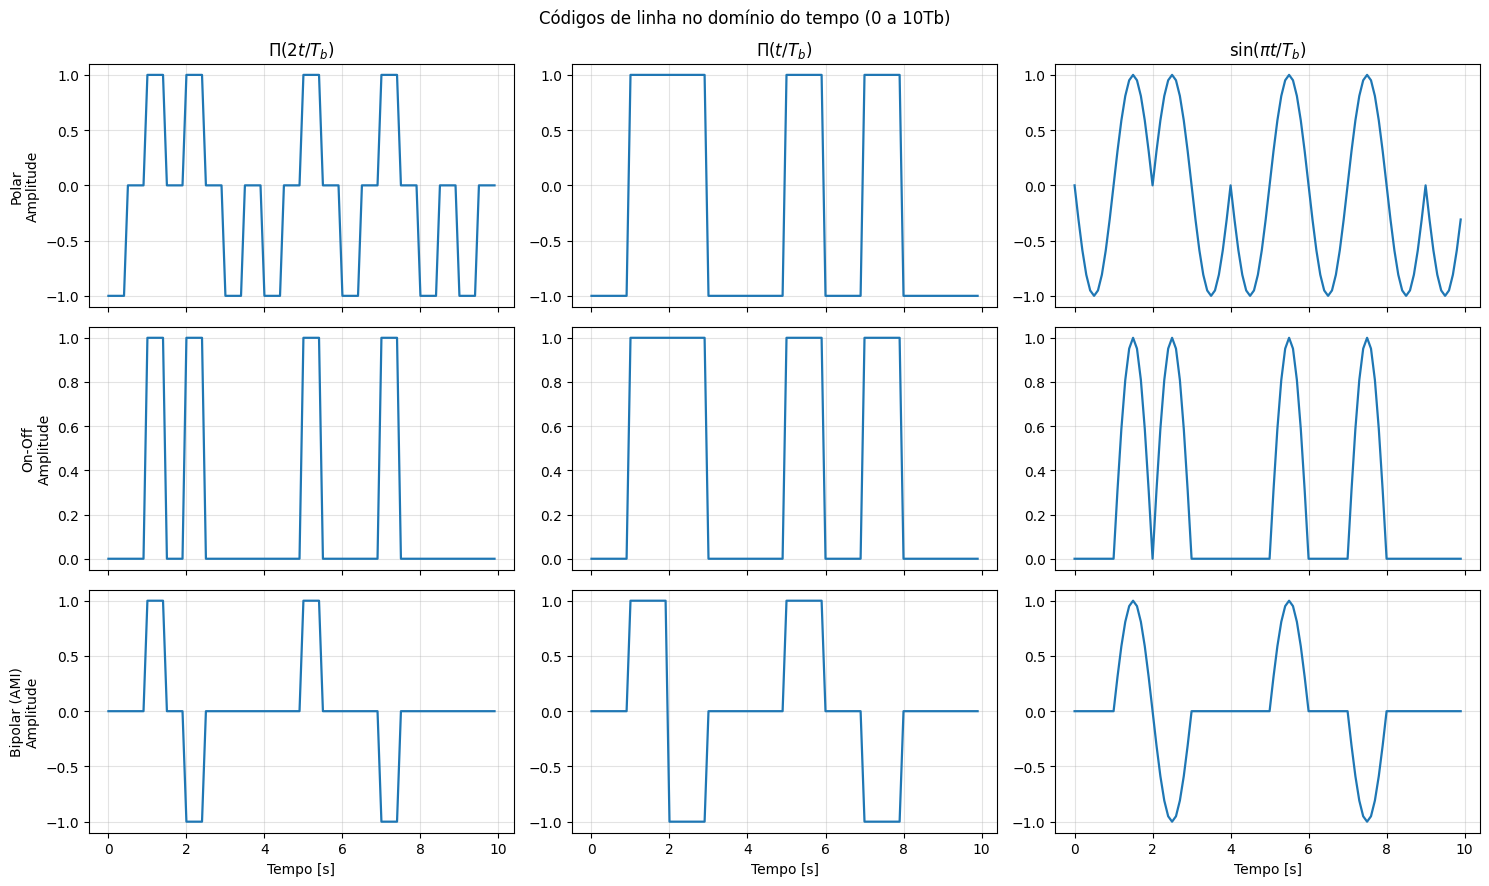

In [14]:
NUM_BITS_TO_SHOW = 10
_fig, _axes = plt.subplots(3, 3, figsize=(15, 9), sharex=True)

_scheme_keys = list(schemes.keys())
_pulse_keys = list(pulses.keys())

for _i, _scheme in enumerate(_scheme_keys):
    for _j, _pulse_name in enumerate(_pulse_keys):
        _ax = _axes[_i, _j]
        _time = results[_scheme][_pulse_name]["time"]
        _signal = results[_scheme][_pulse_name]["signal"]
        _mask = _time < NUM_BITS_TO_SHOW * Tb_s
        _ax.plot(_time[_mask], _signal[_mask], linewidth=1.6)
        _ax.grid(True, alpha=0.35)
        if _i == 0:
            _ax.set_title(pulses[_pulse_name])
        if _j == 0:
            _ax.set_ylabel(f"{schemes[_scheme]}\nAmplitude")
        if _i == 2:
            _ax.set_xlabel("Tempo [s]")

_fig.suptitle("Códigos de linha no domínio do tempo (0 a 10Tb)")
plt.tight_layout()
plt.show()

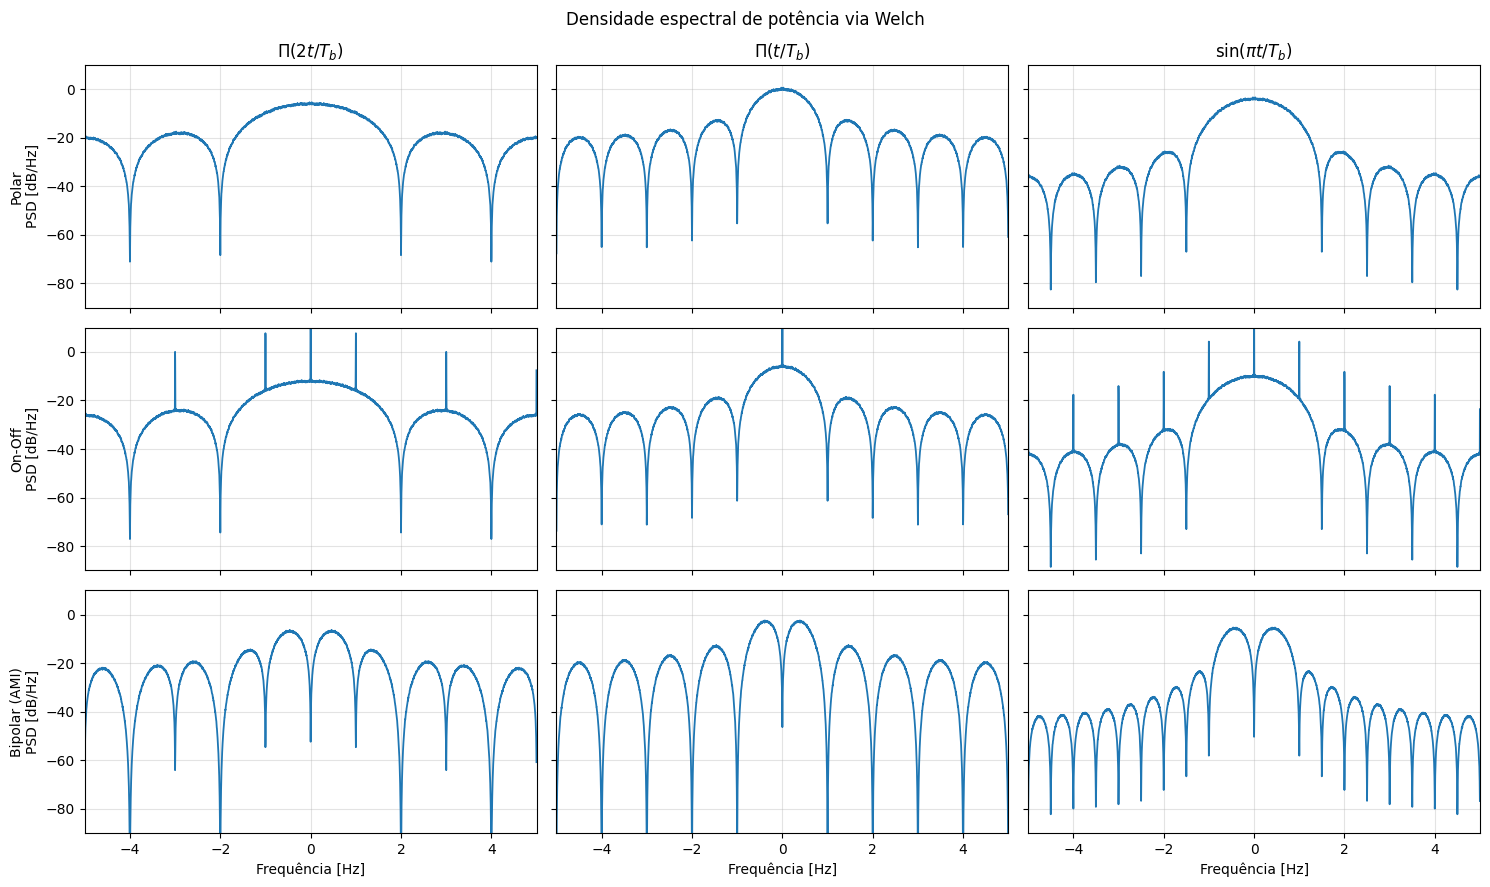

In [15]:
_fig, _axes = plt.subplots(3, 3, figsize=(15, 9), sharex=True, sharey=True)

_scheme_keys = list(schemes.keys())
_pulse_keys = list(pulses.keys())

for _i, _scheme in enumerate(_scheme_keys):
    for _j, _pulse_name in enumerate(_pulse_keys):
        _ax = _axes[_i, _j]
        _freq = results[_scheme][_pulse_name]["freq"]
        _psd_db = results[_scheme][_pulse_name]["psd_db"]
        _ax.plot(_freq, _psd_db, linewidth=1.3)
        _ax.grid(True, alpha=0.35)
        _ax.set_xlim(-fs_hz / 2, fs_hz / 2)
        _ax.set_ylim(-90, 10)

        if _i == 0:
            _ax.set_title(pulses[_pulse_name])
        if _j == 0:
            _ax.set_ylabel(f"{schemes[_scheme]}\nPSD [dB/Hz]")
        if _i == 2:
            _ax.set_xlabel("Frequência [Hz]")

_fig.suptitle("Densidade espectral de potência via Welch")
plt.tight_layout()
plt.show()

In [16]:
rows = []
for scheme_key, scheme_label in schemes.items():
    for pulse_key, pulse_label in pulses.items():
        data = results[scheme_key][pulse_key]
        rows.append(
            {
                "Sinalização": scheme_label,
                "Pulso": pulse_label,
                "Média (indicador DC)": round(data["dc_mean"], 6),
                "1º nulo estimado [Hz]": round(data["first_null_hz"], 6),
            }
        )

mo.ui.table(rows)

table()